# Compare Sr $5s5s \rightarrow 5snl$ matrix elements with NIST

In [1]:
# %matplotlib widget

import matplotlib.pyplot as plt
import numpy as np

import rydstate

## NIST reference values

The NIST ASD line strength of an E1 transition is $S = |\langle J \Vert d \Vert J' \rangle|^2$ in atomic units $(e\,a_0)^2$,
so it is directly comparable to the square of rydstate's reduced matrix elements.

In [2]:
# {(n, s_tot): S in (e a0)^2} from https://physics.nist.gov/PhysRefData/ASD/lines_form.html (retrieved 2026-07-24)
nist_s = {
    (5, 0): 2.91e1,
    (6, 0): 7.1e-2,
    (7, 0): 1.3e-1,
    (8, 0): 3.5e-1,
    (9, 0): 2.09e-1,
    (10, 0): 1.2e-1,
    (11, 0): 6.3e-2,
    (12, 0): 4.0e-2,
    (13, 0): 2.57e-2,
    (14, 0): 1.89e-2,
    (15, 0): 1.4e-2,
    (16, 0): 1.0e-2,
    (17, 0): 7.9e-3,
    (18, 0): 6.6e-3,
    (19, 0): 5.0e-3,
    (20, 0): 4.01e-3,
}

## Bare vs. full operator

The full operator (including the symmetry factor $\sqrt{2}$) is used automatically if "electric_dipole" is specified.
To compute the bare values for comparison without the symmetry factor $\sqrt{2}$, we use the "electric_dipole_rydberg" operator.

In [3]:
n_max = 30
matrix_elements: dict[str, dict[tuple[int, float], float]] = {}

for potential in ["coulomb", "fei_2009"]:
    basis_ns = rydstate.BasisSQDT("Sr88", n=(0, n_max), l_r=(0, 0), potential_class=potential)
    ground_state = basis_ns.sort_states("nu").states[0]
    basis_np = rydstate.BasisSQDT("Sr88", n=(0, n_max), l_r=(1, 1), potential_class=potential)

    matrix_elements[potential + " - bare"] = {
        (state.n, state.calc_exp_qn("s_tot")): state.calc_reduced_matrix_element(
            ground_state, "electric_dipole_rydberg", unit="e a0"
        )
        for state in basis_np.states
    }

    matrix_elements[potential + " - full"] = {
        (state.n, state.calc_exp_qn("s_tot")): state.calc_reduced_matrix_element(
            ground_state, "electric_dipole", unit="e a0"
        )
        for state in basis_np.states
    }

The wavefunction for the radial_ket RadialKet(nu=2.127979643626841, potential=PotentialCoulombStrontium88(l_r=1)) has some issues:
      The wavefunction has 0 nodes, but should have 3 nodes.
The wavefunction for the radial_ket RadialKet(nu=1.545675122591217, potential=PotentialCoulombStrontium88(l_r=0)) has some issues:
      The wavefunction has 1 nodes, but should have 4 nodes.
      The integration for l=0 did stop at 0.31 (should be close to zero).
The wavefunction for the radial_ket RadialKet(nu=3.045213644985167, potential=PotentialCoulombStrontium88(l_r=1)) has some issues:
      The wavefunction has 1 nodes, but should have 4 nodes.
The wavefunction for the radial_ket RadialKet(nu=3.9522901100766417, potential=PotentialCoulombStrontium88(l_r=1)) has some issues:
      The wavefunction has 2 nodes, but should have 5 nodes.
The wavefunction for the radial_ket RadialKet(nu=5.6236817451158005, potential=PotentialCoulombStrontium88(l_r=1)) has some issues:
      The wavefunction ha

## Comparison plot

Left: the matrix elements themselves.
Right: the ratio of the calculated matrix elements to the NIST values.

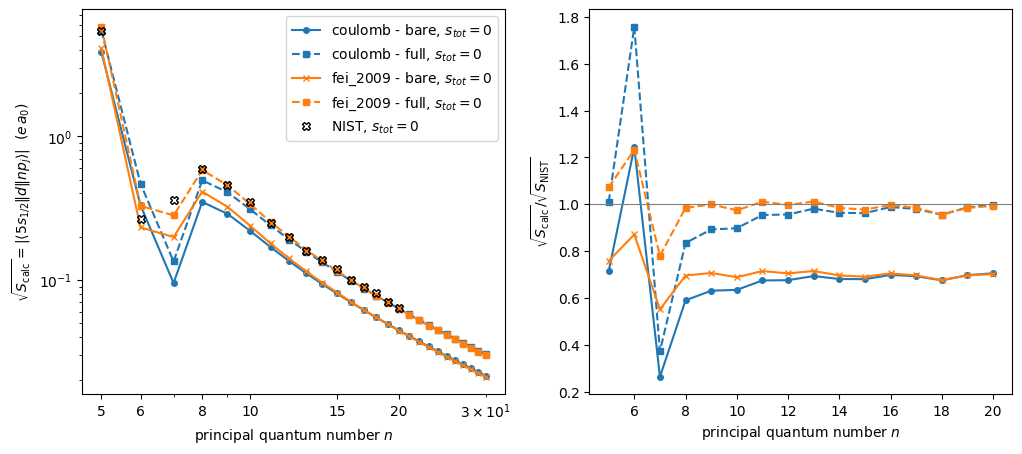

In [4]:
fig, (ax_me, ax_ratio) = plt.subplots(1, 2, figsize=(12, 5))

colors = ["C0", "C0", "C1", "C1", "C2", "C2", "C3", "C3"]
linestyles = ["-", "--", "-", "--", "-", "--", "-", "--"]
markers = ["o", "s", "x", "s", "^", "v", "o", "s", "^", "v"]

s_tot = 0
s_tot_label = rf"$s_{{tot}}={s_tot}$"
n_nist = sorted(n for (n, _s_tot) in nist_s if _s_tot == s_tot)

for label, me in matrix_elements.items():
    n_list = [n for (n, _s_tot) in me if _s_tot == s_tot]
    style = {"color": colors.pop(0), "linestyle": linestyles.pop(0), "marker": markers.pop(0), "markersize": 4}
    ax_me.plot(n_list, [abs(me[(n, s_tot)]) for n in n_list], **style, label=f"{label}, {s_tot_label}")
    ax_ratio.plot(n_nist, np.abs([me[(n, s_tot)] / np.sqrt(nist_s[(n, s_tot)]) for n in n_nist]), **style)

ax_me.plot(
    n_nist,
    [np.sqrt(nist_s[(n, s_tot)]) for n in n_nist],
    color="k",
    linestyle="none",
    marker="X",
    markeredgecolor="black",
    fillstyle="none",
    label=f"NIST, {s_tot_label}",
)

ax_me.set_xscale("log")
ax_me.set_yscale("log")
ax_me.set_xticks([5, 6, 8, 10, 15, 20], labels=["5", "6", "8", "10", "15", "20"])
ax_me.set_xlabel("principal quantum number $n$")
ax_me.set_ylabel(r"$\sqrt{S_\mathrm{calc}} = |\langle 5s_{1/2} \Vert d \Vert np_j \rangle|$  ($e\,a_0$)")
ax_me.legend()

ax_ratio.axhline(1, color="gray", lw=0.8)
ax_ratio.set_xlabel("principal quantum number $n$")
ax_ratio.set_ylabel(r"$\sqrt{S_\mathrm{calc}} / \sqrt{S_\mathrm{NIST}}$")

plt.show()